In [53]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_circles,load_iris
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression as lr
from sklearn.tree import DecisionTreeClassifier as dtc 
from sklearn.neighbors import KNeighborsClassifier as knc
from sklearn.model_selection import cross_val_score


In [54]:
x,y=make_circles(n_samples=100,noise=0.06)

In [55]:
x.shape
iris=load_iris()
iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [56]:
df=iris.data

df=pd.DataFrame(df)
df.columns=  ['sepal length (cm)','sepal width (cm)',
  'petal length (cm)',
  'petal width (cm)'
  ]
y=iris.target
df["species"]=y

In [57]:
new_df=df[df["species"]!=0] [["sepal length (cm)",'sepal width (cm)',"species"]]

In [58]:
new_df
x=df[['sepal length (cm)','sepal width (cm)']]
y=df["species"]

In [59]:
clf1=lr()
clf2=dtc()
clf3=knc()

In [60]:
estimators=[('lr',clf1),('dtc',clf2),('knc',clf3)]

In [61]:
for i in estimators:
    X=cross_val_score(i[1],x,y,cv=10,scoring='accuracy')
    print(i[0],np.mean(X))

lr 0.8066666666666669
dtc 0.6666666666666667
knc 0.76


In [62]:
from sklearn.ensemble import VotingClassifier as vc


In [63]:
vcc=vc(voting='soft',estimators=estimators,weights=[1,2,3])
np.mean(cross_val_score(vcc,x,y,cv=10,scoring='accuracy'))

np.float64(0.7133333333333333)

In [64]:
for i in range(1,5):
    for j in range(1,5):
        for k in range(1,5):
            vcc=vc(voting='soft',estimators=estimators,weights=[i,j,k])
            print(f'{i,j,k} {np.mean(cross_val_score(vcc,x,y,cv=10,scoring='accuracy'))}')

(1, 1, 1) 0.7133333333333333
(1, 1, 2) 0.7266666666666667
(1, 1, 3) 0.7266666666666667
(1, 1, 4) 0.7333333333333333
(1, 2, 1) 0.6733333333333333
(1, 2, 2) 0.6799999999999999
(1, 2, 3) 0.7266666666666667
(1, 2, 4) 0.74
(1, 3, 1) 0.68
(1, 3, 2) 0.6733333333333333
(1, 3, 3) 0.6866666666666666
(1, 3, 4) 0.7000000000000001
(1, 4, 1) 0.6733333333333333
(1, 4, 2) 0.6799999999999999
(1, 4, 3) 0.6799999999999999
(1, 4, 4) 0.6933333333333334
(2, 1, 1) 0.7333333333333334
(2, 1, 2) 0.74
(2, 1, 3) 0.7333333333333333
(2, 1, 4) 0.74
(2, 2, 1) 0.6866666666666666
(2, 2, 2) 0.7066666666666667
(2, 2, 3) 0.7266666666666667
(2, 2, 4) 0.7266666666666667
(2, 3, 1) 0.6933333333333334
(2, 3, 2) 0.6933333333333334
(2, 3, 3) 0.6866666666666666
(2, 3, 4) 0.7133333333333334
(2, 4, 1) 0.6799999999999999
(2, 4, 2) 0.66
(2, 4, 3) 0.6866666666666666
(2, 4, 4) 0.6733333333333333
(3, 1, 1) 0.7333333333333334
(3, 1, 2) 0.7466666666666667
(3, 1, 3) 0.7533333333333333
(3, 1, 4) 0.7533333333333333
(3, 2, 1) 0.72666666666666

In [65]:
from sklearn.datasets import make_classification 
import seaborn as sns

In [66]:
x,y=make_classification(n_samples=1000,n_features=2,n_informative=2,n_repeated=0,n_redundant=0)

<Axes: >

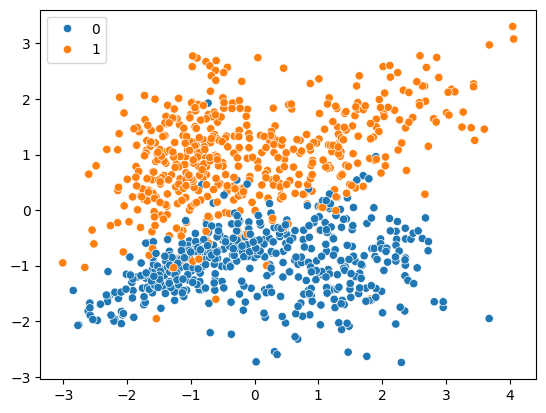

In [67]:
sns.scatterplot(x=x[:,0],y=x[:,1],hue=y)

In [68]:

dtc1=dtc(max_depth=5)

In [69]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42)

In [70]:
x_train


array([[-0.69523631, -0.77153609],
       [-2.60998178, -1.81675474],
       [-0.61722011, -0.87769286],
       ...,
       [-1.77898274, -0.95201788],
       [-0.4288552 ,  0.43800098],
       [-0.98145796,  1.94521895]])

In [71]:

dtc1.fit(x_train,y_train)
dtc1.predict(x_test
             )

array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0,

[Text(0.4722222222222222, 0.9166666666666666, 'x[1] <= -0.05\ngini = 0.5\nsamples = 670\nvalue = [331.0, 339.0]'),
 Text(0.2152777777777778, 0.75, 'x[1] <= -0.392\ngini = 0.184\nsamples = 352\nvalue = [316, 36]'),
 Text(0.34375, 0.8333333333333333, 'True  '),
 Text(0.08333333333333333, 0.5833333333333334, 'x[0] <= -2.89\ngini = 0.107\nsamples = 300\nvalue = [283, 17]'),
 Text(0.05555555555555555, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.1111111111111111, 0.4166666666666667, 'x[1] <= -1.039\ngini = 0.101\nsamples = 299\nvalue = [283, 16]'),
 Text(0.05555555555555555, 0.25, 'x[1] <= -1.597\ngini = 0.014\nsamples = 147\nvalue = [146, 1]'),
 Text(0.027777777777777776, 0.08333333333333333, 'gini = 0.043\nsamples = 45\nvalue = [44, 1]'),
 Text(0.08333333333333333, 0.08333333333333333, 'gini = 0.0\nsamples = 102\nvalue = [102, 0]'),
 Text(0.16666666666666666, 0.25, 'x[0] <= -2.008\ngini = 0.178\nsamples = 152\nvalue = [137, 15]'),
 Text(0.1388888888888889, 0.083

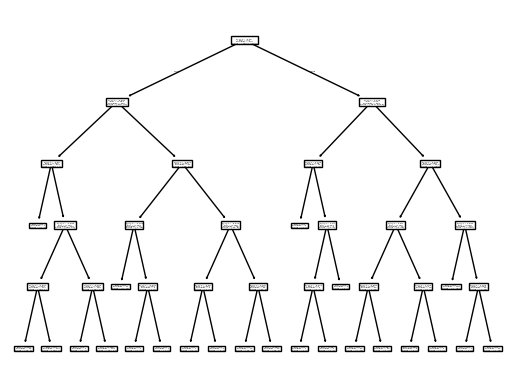

In [72]:
from sklearn.tree import plot_tree
plot_tree(dtc1)

<Axes: >

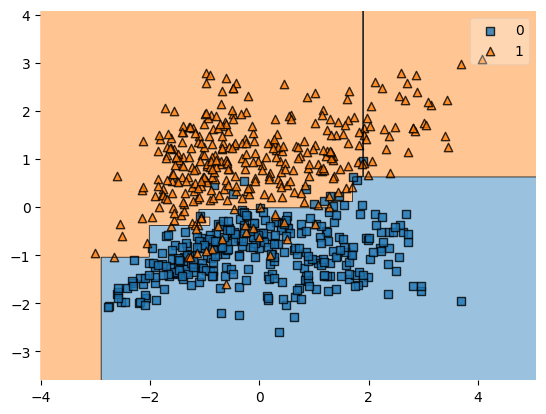

In [73]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x_train,y_train,clf=dtc1)

In [74]:
from sklearn.ensemble import RandomForestClassifier as rfc

In [75]:
rf=rfc()

In [76]:
rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<Axes: >

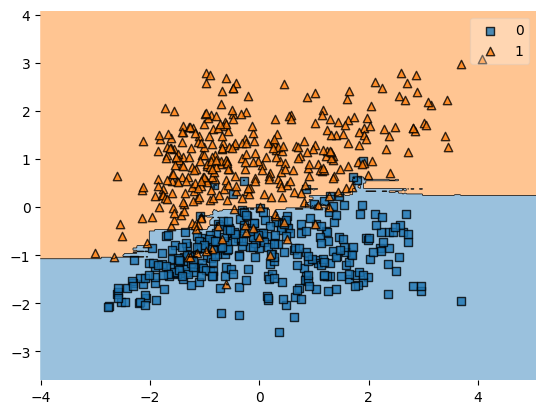

In [77]:
plot_decision_regions(x_train,y_train,clf=rf)

In [78]:
from sklearn.model_selection import GridSearchCV

In [83]:
paramaters={'n_estimators':[450,500,550,600,650],
            "criterion":['gini', 'entropy', 'log_loss'],"max_depth":[5,6,7,8,9,10]}

In [84]:
gf=GridSearchCV(estimator=rf,param_grid=paramaters)

In [85]:
gf.fit(x_train,y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [5, 6, ...], 'n_estimators': [450, 500, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,550


In [87]:
gf.set_params

<bound method BaseEstimator.set_params of GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [5, 6, 7, 8, 9, 10],
                         'n_estimators': [450, 500, 550, 600, 650]})>

<Axes: >

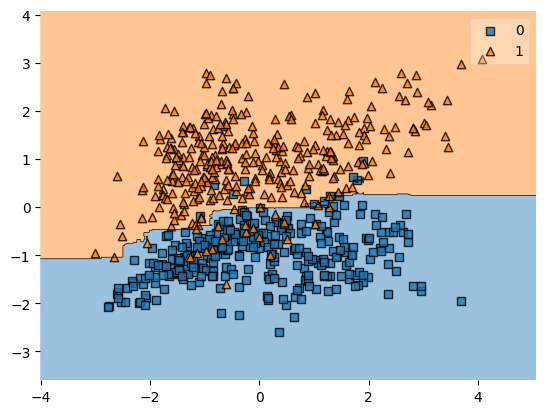

In [88]:
plot_decision_regions(x_train,y_train,clf=gf)

In [92]:
from sklearn.metrics import confusion_matrix,accuracy_score
confusion_matrix(y_test,gf.predict(x_test))

array([[157,   9],
       [ 15, 149]])

In [ ]:
accuracy_score(y_test,gf.predict(x_test))

0.9272727272727272